# 🔮 Tomorrow's Market Predictions EDA

**Predictive Analysis for Gap Up/Down & Short Opportunities**

This notebook focuses on:
- 📈 **Gap Up Predictions**: Stocks likely to gap up tomorrow
- 📉 **Gap Down Predictions**: Stocks likely to gap down tomorrow  
- 🩳 **Short Opportunities**: High probability short setups
- 📊 **Visual Predictions**: Heavy matplotlib visualizations
- 🎯 **Actionable Insights**: Ready-to-trade opportunities

---

In [1]:
# Core imports for predictions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# TradingView screener
from tradingview_screener import Query, Column
import rookiepy

# Create column function alias for compatibility  
col = Column

# Rich for better output
from rich.console import Console
from rich.panel import Panel
console = Console()

# Matplotlib settings for better visuals
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#1e1e1e'
plt.rcParams['axes.facecolor'] = '#2d2d2d'
plt.rcParams['axes.edgecolor'] = '#ffffff'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'
plt.rcParams['font.size'] = 10

print(f"🔮 Predictions Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("🚀 Tomorrow's Market Predictions EDA Loaded!")

🔮 Predictions Analysis Date: 2025-07-24 22:52:38
🚀 Tomorrow's Market Predictions EDA Loaded!


In [2]:
# TradingView Setup
def get_tradingview_cookies():
    """Get TradingView cookies for live data"""
    try:
        cookies_raw = rookiepy.chrome(['.tradingview.com'])
        cookies = rookiepy.to_cookiejar(cookies_raw)
        console.print("[green]✅ TradingView cookies loaded - Live data enabled[/green]")
        return cookies
    except Exception:
        try:
            cookies_raw = rookiepy.firefox(['.tradingview.com'])
            cookies = rookiepy.to_cookiejar(cookies_raw)
            console.print("[green]✅ TradingView cookies loaded from Firefox[/green]")
            return cookies
        except Exception as e:
            console.print(f"[red]❌ Could not load cookies: {e}[/red]")
            return None

tv_cookies = get_tradingview_cookies()
console.print("[blue]🎯 Focus: Tomorrow's Gap & Short Predictions[/blue]")

✅ TradingView cookies loaded - Live data enabled

🎯 Focus: Tomorrow's Gap & Short Predictions

## 📈 Gap Up Prediction Analysis

Identifying stocks with high probability of gapping up tomorrow based on:
- Pre-market momentum
- Technical breakouts
- Volume surges
- News sentiment proxies

In [3]:
def get_gap_up_candidates():
    """Screen for QUALITY stocks likely to gap up tomorrow"""
    col = Column
    
    gap_up_query = (Query()
        .select('name', 'close', 'change', 'volume', 'premarket_change', 'postmarket_change',
                'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                'EMA20', 'EMA50', 'BB.upper', 'BB.lower', 'ATR',
                'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                'market_cap_basic', 'sector')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 10_000_000_000,  # 10B+ market cap (QUALITY STOCKS ONLY)
            col('close') > 200,  # Minimum ₹200 price (NO PENNY STOCKS)
            col('change') > 2,  # Strong intraday performance
            col('relative_volume_10d_calc') > 1.5,  # Above average volume
            col('RSI').between(45, 75),  # Not oversold, not extreme overbought
            col('close') > col('EMA20'),  # Above short-term trend
            col('MACD.macd') > col('MACD.signal'),  # Bullish MACD
            col('volume') > 1_000_000  # HIGH liquidity requirement for quality stocks
        )
        .order_by('relative_volume_10d_calc', ascending=False)
        .limit(25))
    
    try:
        data = gap_up_query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            
            # Convert numeric columns
            numeric_cols = ['close', 'change', 'volume', 'premarket_change', 'postmarket_change',
                          'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                          'EMA20', 'EMA50', 'BB.upper', 'BB.lower', 'ATR',
                          'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                          'market_cap_basic']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            
            # Calculate prediction scores
            df['gap_up_score'] = 0
            
            # Volume momentum (40% weight)
            if 'relative_volume_10d_calc' in df.columns:
                df['gap_up_score'] += np.clip(df['relative_volume_10d_calc'] * 10, 0, 40)
            
            # Price momentum (30% weight)
            if 'change' in df.columns:
                df['gap_up_score'] += np.clip(df['change'] * 3, 0, 30)
            
            # Technical strength (30% weight)
            if 'RSI' in df.columns:
                df['gap_up_score'] += np.clip((df['RSI'] - 50) * 0.6, 0, 30)
            
            # Distance from 52-week high bonus
            if all(col in df.columns for col in ['close', 'price_52_week_high']):
                df['distance_from_52w_high'] = ((df['close'] / df['price_52_week_high']) - 1) * 100
                df['gap_up_score'] += np.where(df['distance_from_52w_high'] > -5, 10, 0)  # Bonus if near highs
            
            # Bollinger Band breakout bonus
            if all(col in df.columns for col in ['close', 'BB.upper']):
                df['gap_up_score'] += np.where(df['close'] > df['BB.upper'], 15, 0)
            
            # Quality stock bonus (large market cap)
            if 'market_cap_basic' in df.columns:
                df['gap_up_score'] += np.where(df['market_cap_basic'] > 50_000_000_000, 5, 0)  # 50B+ bonus
            
            df = df.sort_values('gap_up_score', ascending=False)
            console.print(f"[green]✅ Found {len(df)} QUALITY gap up candidates[/green]")
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Gap up screening failed: {e}[/red]")
        return None

# Get gap up candidates
with console.status("[bold green]Scanning for QUALITY gap up opportunities..."):
    gap_up_df = get_gap_up_candidates()

if gap_up_df is not None:
    print(f"📈 Found {len(gap_up_df)} QUALITY Gap Up Candidates")
    print(f"💎 All stocks have >₹200 price and >₹10,000 Cr market cap")
    
    # Display top candidates
    top_gap_up = gap_up_df.head(10)[['name', 'close', 'change', 'relative_volume_10d_calc', 'gap_up_score']]
    top_gap_up.columns = ['Stock', 'Price', 'Change %', 'Vol Ratio', 'Gap Score']
    print("\n🏆 TOP QUALITY GAP UP CANDIDATES:")
    print(top_gap_up.to_string(index=False, float_format='%.2f'))
else:
    print("❌ No quality gap up candidates found")

Output()

✅ Found 15 QUALITY gap up candidates

📈 Found 15 QUALITY Gap Up Candidates
💎 All stocks have >₹200 price and >₹10,000 Cr market cap

🏆 TOP QUALITY GAP UP CANDIDATES:
    Stock   Price  Change %  Vol Ratio  Gap Score
   VIJAYA 1121.15     10.16      42.12     104.94
     POCL 1095.30     15.48      13.50      99.77
  IPCALAB 1540.80      5.54       7.66      90.92
SHYAMMETL  951.90      2.82       3.77      89.11
    WABAG 1640.00      2.95       4.23      81.89
     JBMA  674.05      4.46       7.86      78.59
   PENIND  262.67      4.00       2.56      75.54
     IGIL  413.05      2.01       3.70      73.42
   FORTIS  846.55      2.77       2.21      72.39
  GRAVITA 1812.90      5.10       8.16      64.32


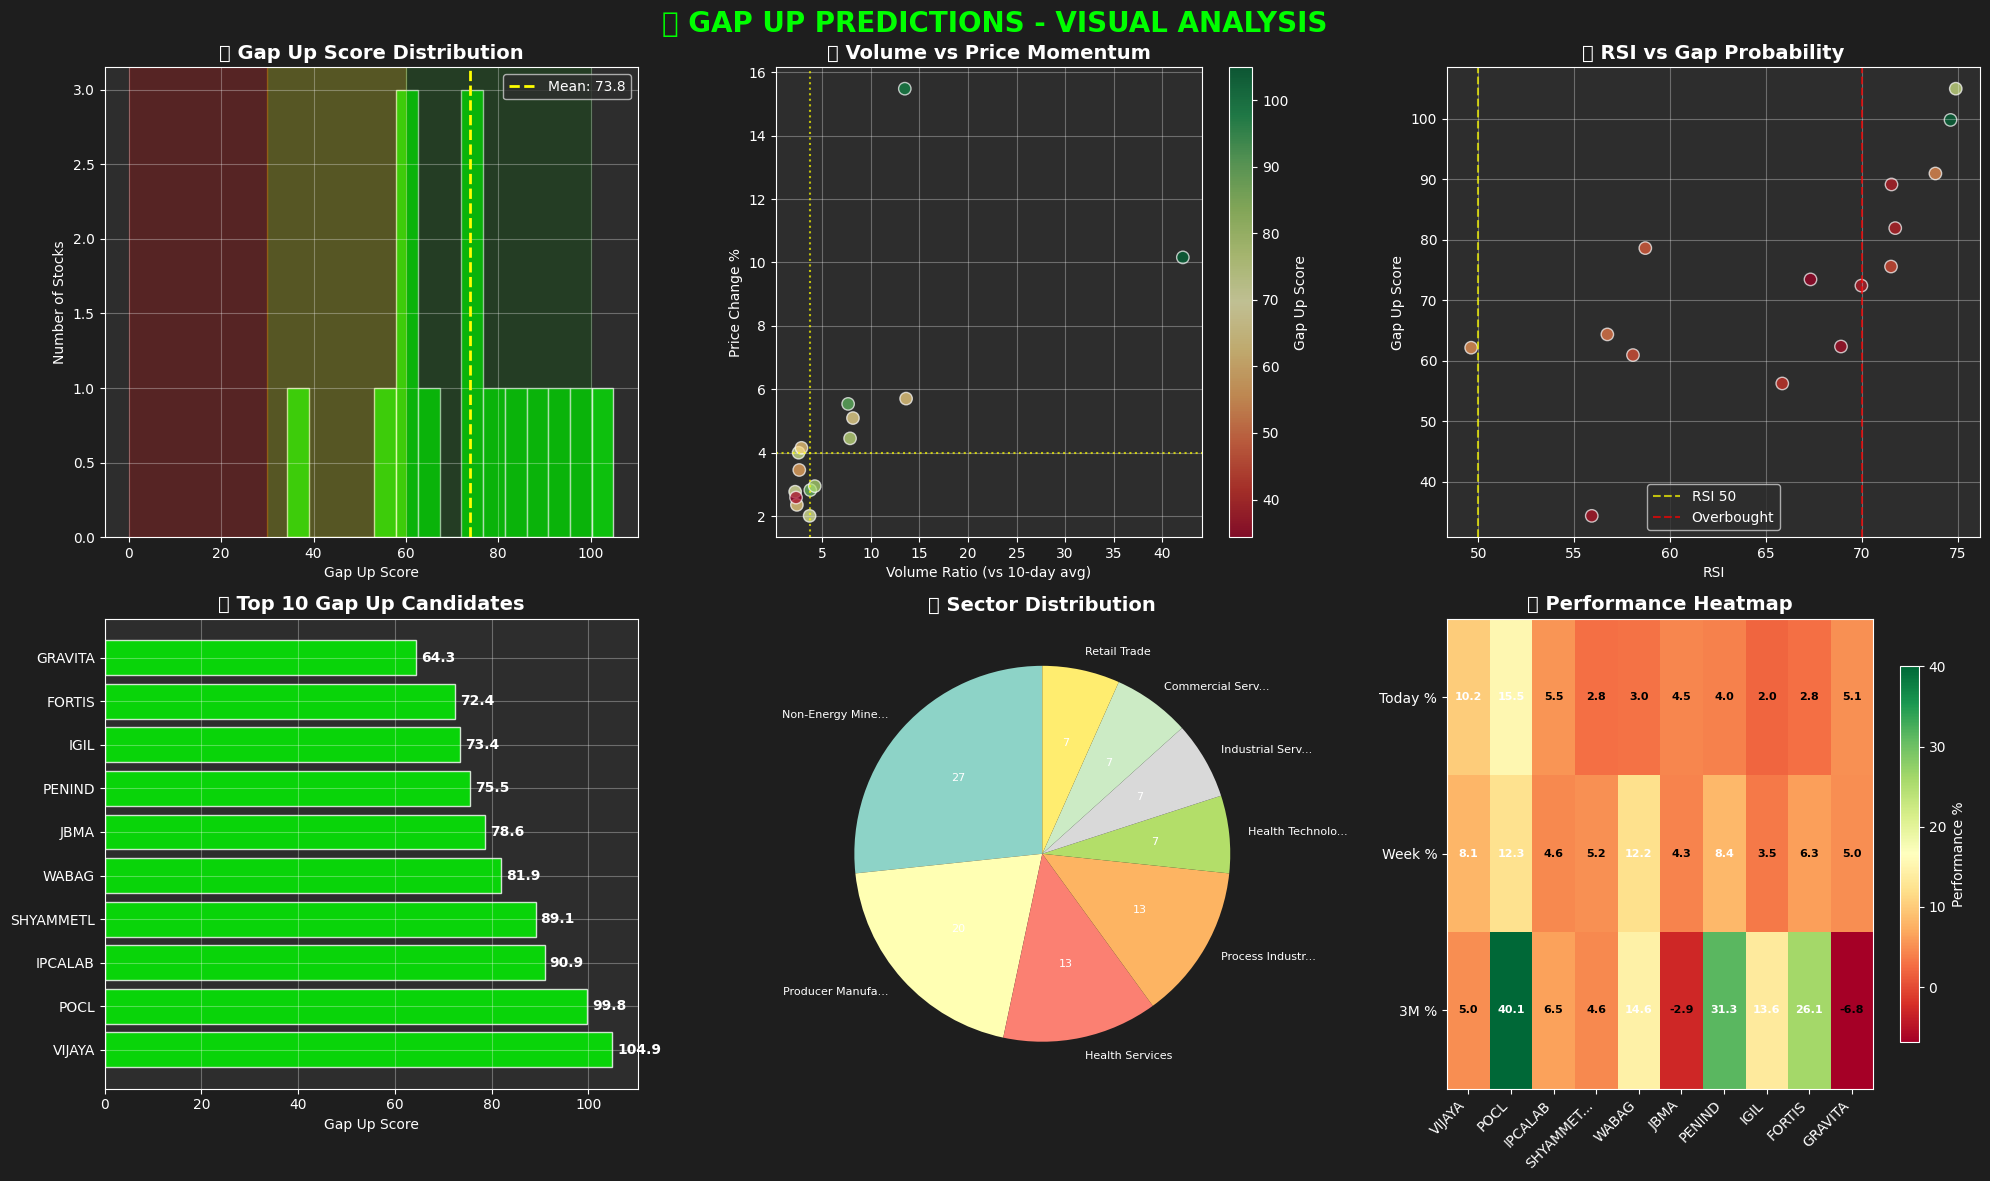


📊 GAP UP PROBABILITY BREAKDOWN:
🟢 High Probability (>60): 13 stocks
🟡 Medium Probability (30-60): 2 stocks
🟠 Low Probability (<30): 0 stocks


In [4]:
# Visual Analysis of Gap Up Candidates
if gap_up_df is not None and len(gap_up_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('📈 GAP UP PREDICTIONS - VISUAL ANALYSIS', fontsize=20, fontweight='bold', color='#00ff00')
    
    # 1. Gap Up Score Distribution (Top Left)
    ax1 = axes[0, 0]
    ax1.hist(gap_up_df['gap_up_score'], bins=15, color='#00ff00', alpha=0.7, edgecolor='white')
    ax1.axvline(gap_up_df['gap_up_score'].mean(), color='#ffff00', linestyle='--', linewidth=2, 
               label=f'Mean: {gap_up_df["gap_up_score"].mean():.1f}')
    ax1.set_title('🎯 Gap Up Score Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Gap Up Score')
    ax1.set_ylabel('Number of Stocks')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add score interpretation
    ax1.axvspan(0, 30, alpha=0.2, color='red', label='Low Probability')
    ax1.axvspan(30, 60, alpha=0.2, color='yellow', label='Medium Probability')
    ax1.axvspan(60, 100, alpha=0.2, color='green', label='High Probability')
    
    # 2. Volume vs Price Change Scatter (Top Middle)
    ax2 = axes[0, 1]
    scatter = ax2.scatter(gap_up_df['relative_volume_10d_calc'], gap_up_df['change'], 
                         c=gap_up_df['gap_up_score'], cmap='RdYlGn', s=80, alpha=0.7, edgecolor='white')
    ax2.set_title('📊 Volume vs Price Momentum', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Volume Ratio (vs 10-day avg)')
    ax2.set_ylabel('Price Change %')
    plt.colorbar(scatter, ax=ax2, label='Gap Up Score')
    ax2.grid(True, alpha=0.3)
    
    # Add quadrant lines
    ax2.axhline(y=gap_up_df['change'].median(), color='yellow', linestyle=':', alpha=0.7)
    ax2.axvline(x=gap_up_df['relative_volume_10d_calc'].median(), color='yellow', linestyle=':', alpha=0.7)
    
    # 3. RSI vs Gap Score (Top Right)
    ax3 = axes[0, 2]
    ax3.scatter(gap_up_df['RSI'], gap_up_df['gap_up_score'], 
               c=gap_up_df['change'], cmap='RdYlGn', s=80, alpha=0.7, edgecolor='white')
    ax3.set_title('📈 RSI vs Gap Probability', fontsize=14, fontweight='bold')
    ax3.set_xlabel('RSI')
    ax3.set_ylabel('Gap Up Score')
    ax3.axvline(x=50, color='yellow', linestyle='--', alpha=0.7, label='RSI 50')
    ax3.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Top 10 Candidates Bar Chart (Bottom Left)
    ax4 = axes[1, 0]
    top_10 = gap_up_df.head(10)
    colors = ['#00ff00' if score > 60 else '#ffff00' if score > 30 else '#ff6600' 
              for score in top_10['gap_up_score']]
    
    bars = ax4.barh(range(len(top_10)), top_10['gap_up_score'], color=colors, alpha=0.8, edgecolor='white')
    ax4.set_yticks(range(len(top_10)))
    ax4.set_yticklabels([name[:10] + '...' if len(name) > 10 else name for name in top_10['name']])
    ax4.set_title('🏆 Top 10 Gap Up Candidates', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Gap Up Score')
    
    # Add score labels
    for i, (bar, score) in enumerate(zip(bars, top_10['gap_up_score'])):
        ax4.text(score + 1, i, f'{score:.1f}', ha='left', va='center', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # 5. Sector Distribution (Bottom Middle)
    ax5 = axes[1, 1]
    if 'sector' in gap_up_df.columns:
        sector_counts = gap_up_df['sector'].value_counts().head(8)
        colors_sector = plt.cm.Set3(np.linspace(0, 1, len(sector_counts)))
        
        wedges, texts, autotexts = ax5.pie(sector_counts.values, 
                                          labels=[s[:15] + '...' if len(s) > 15 else s for s in sector_counts.index],
                                          colors=colors_sector, autopct='%1.0f', startangle=90,
                                          textprops={'fontsize': 8})
        ax5.set_title('🏢 Sector Distribution', fontsize=14, fontweight='bold')
    else:
        ax5.text(0.5, 0.5, 'Sector data\nnot available', ha='center', va='center', 
                transform=ax5.transAxes, fontsize=12, color='yellow')
        ax5.set_title('🏢 Sector Distribution - No Data', fontsize=14, fontweight='bold')
    
    # 6. Price Performance Heatmap (Bottom Right)
    ax6 = axes[1, 2]
    # Create performance matrix
    performance_data = top_10[['change', 'Perf.W', 'Perf.3M']].fillna(0)
    if len(performance_data) > 0:
        im = ax6.imshow(performance_data.T, cmap='RdYlGn', aspect='auto', 
                       vmin=performance_data.min().min(), vmax=performance_data.max().max())
        
        ax6.set_xticks(range(len(top_10)))
        ax6.set_xticklabels([name[:8] + '...' if len(name) > 8 else name for name in top_10['name']], 
                           rotation=45, ha='right')
        ax6.set_yticks(range(3))
        ax6.set_yticklabels(['Today %', 'Week %', '3M %'])
        ax6.set_title('📊 Performance Heatmap', fontsize=14, fontweight='bold')
        
        # Add text annotations
        for i in range(len(performance_data.columns)):
            for j in range(len(top_10)):
                value = performance_data.iloc[j, i]
                ax6.text(j, i, f'{value:.1f}', ha='center', va='center', 
                        color='white' if abs(value) > performance_data.std().mean() else 'black',
                        fontweight='bold', fontsize=8)
        
        plt.colorbar(im, ax=ax6, shrink=0.8, label='Performance %')
    else:
        ax6.text(0.5, 0.5, 'Performance data\nnot available', ha='center', va='center', 
                transform=ax6.transAxes, fontsize=12, color='yellow')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    high_prob = len(gap_up_df[gap_up_df['gap_up_score'] > 60])
    med_prob = len(gap_up_df[(gap_up_df['gap_up_score'] > 30) & (gap_up_df['gap_up_score'] <= 60)])
    low_prob = len(gap_up_df[gap_up_df['gap_up_score'] <= 30])
    
    print(f"\n📊 GAP UP PROBABILITY BREAKDOWN:")
    print(f"🟢 High Probability (>60): {high_prob} stocks")
    print(f"🟡 Medium Probability (30-60): {med_prob} stocks")
    print(f"🟠 Low Probability (<30): {low_prob} stocks")
    
else:
    print("No gap up data available for visualization")

## 📉 Gap Down Prediction Analysis

Identifying stocks with high probability of gapping down tomorrow based on:
- Bearish technical patterns
- Volume selling pressure
- Weakness indicators
- Risk-off sentiment

In [5]:
def get_gap_down_candidates():
    """Screen for QUALITY stocks likely to gap down tomorrow"""
    col = Column
    
    gap_down_query = (Query()
        .select('name', 'close', 'change', 'volume', 'premarket_change', 'postmarket_change',
                'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                'EMA20', 'EMA50', 'BB.upper', 'BB.lower', 'ATR',
                'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                'market_cap_basic', 'sector', 'Stoch.RSI.K', 'ADX')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 10_000_000_000,  # 10B+ market cap (QUALITY STOCKS ONLY)
            col('close') > 200,  # Minimum ₹200 price (NO PENNY STOCKS)
            col('change') < -1.5,  # Weak intraday performance
            col('relative_volume_10d_calc') > 1.2,  # Above average volume
            col('RSI') < 55,  # Not overbought
            col('close') < col('EMA20'),  # Below short-term trend
            col('MACD.macd') < col('MACD.signal'),  # Bearish MACD
            col('volume') > 1_000_000  # HIGH liquidity requirement for quality stocks
        )
        .order_by('change', ascending=True)  # Most negative first
        .limit(25))
    
    try:
        data = gap_down_query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            
            # Convert numeric columns
            numeric_cols = ['close', 'change', 'volume', 'premarket_change', 'postmarket_change',
                          'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                          'EMA20', 'EMA50', 'BB.upper', 'BB.lower', 'ATR',
                          'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                          'market_cap_basic', 'Stoch.RSI.K', 'ADX']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            
            # Calculate gap down prediction scores
            df['gap_down_score'] = 0
            
            # Price weakness (40% weight)
            if 'change' in df.columns:
                df['gap_down_score'] += np.clip(abs(df['change']) * 4, 0, 40)
            
            # Volume pressure (30% weight)
            if 'relative_volume_10d_calc' in df.columns:
                df['gap_down_score'] += np.clip(df['relative_volume_10d_calc'] * 10, 0, 30)
            
            # Technical weakness (30% weight)
            if 'RSI' in df.columns:
                df['gap_down_score'] += np.clip((50 - df['RSI']) * 0.6, 0, 30)
            
            # Distance from EMA20 penalty
            if all(col in df.columns for col in ['close', 'EMA20']):
                df['distance_from_ema20'] = ((df['close'] / df['EMA20']) - 1) * 100
                df['gap_down_score'] += np.where(df['distance_from_ema20'] < -2, 10, 0)  # Bonus if well below EMA20
            
            # Bollinger Band breakdown bonus
            if all(col in df.columns for col in ['close', 'BB.lower']):
                df['gap_down_score'] += np.where(df['close'] < df['BB.lower'], 15, 0)
            
            # Weekly performance penalty
            if 'Perf.W' in df.columns:
                df['gap_down_score'] += np.where(df['Perf.W'] < -3, 10, 0)
            
            # Quality stock bonus (easier to short quality names)
            if 'market_cap_basic' in df.columns:
                df['gap_down_score'] += np.where(df['market_cap_basic'] > 50_000_000_000, 5, 0)  # 50B+ bonus
            
            df = df.sort_values('gap_down_score', ascending=False)
            console.print(f"[green]✅ Found {len(df)} QUALITY gap down candidates[/green]")
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Gap down screening failed: {e}[/red]")
        return None

# Get gap down candidates
with console.status("[bold red]Scanning for QUALITY gap down opportunities..."):
    gap_down_df = get_gap_down_candidates()

if gap_down_df is not None:
    print(f"📉 Found {len(gap_down_df)} QUALITY Gap Down Candidates")
    print(f"💎 All stocks have >₹200 price and >₹10,000 Cr market cap")
    
    # Display top candidates
    top_gap_down = gap_down_df.head(10)[['name', 'close', 'change', 'relative_volume_10d_calc', 'gap_down_score']]
    top_gap_down.columns = ['Stock', 'Price', 'Change %', 'Vol Ratio', 'Gap Score']
    print("\n📉 TOP QUALITY GAP DOWN CANDIDATES:")
    print(top_gap_down.to_string(index=False, float_format='%.2f'))
else:
    print("❌ No quality gap down candidates found")

Output()

✅ Found 17 QUALITY gap down candidates

📉 Found 17 QUALITY Gap Down Candidates
💎 All stocks have >₹200 price and >₹10,000 Cr market cap

📉 TOP QUALITY GAP DOWN CANDIDATES:
     Stock   Price  Change %  Vol Ratio  Gap Score
   COFORGE 1676.00     -9.39       8.85     122.17
PERSISTENT 5174.00     -7.70       7.87     113.37
 NESTLEIND 2322.10     -5.32       5.36      99.43
   VERANDA  221.59     -9.61       3.55      91.68
       ACC 1890.00     -3.08       3.57      89.87
  MARKSANS  231.60     -2.36       2.41      84.40
       MGL 1428.50     -3.70       2.26      82.11
ADANIENSOL  849.05     -1.63       2.46      78.13
       IGL  207.23     -1.50       2.26      75.13
POONAWALLA  432.45     -3.14       1.66      75.13


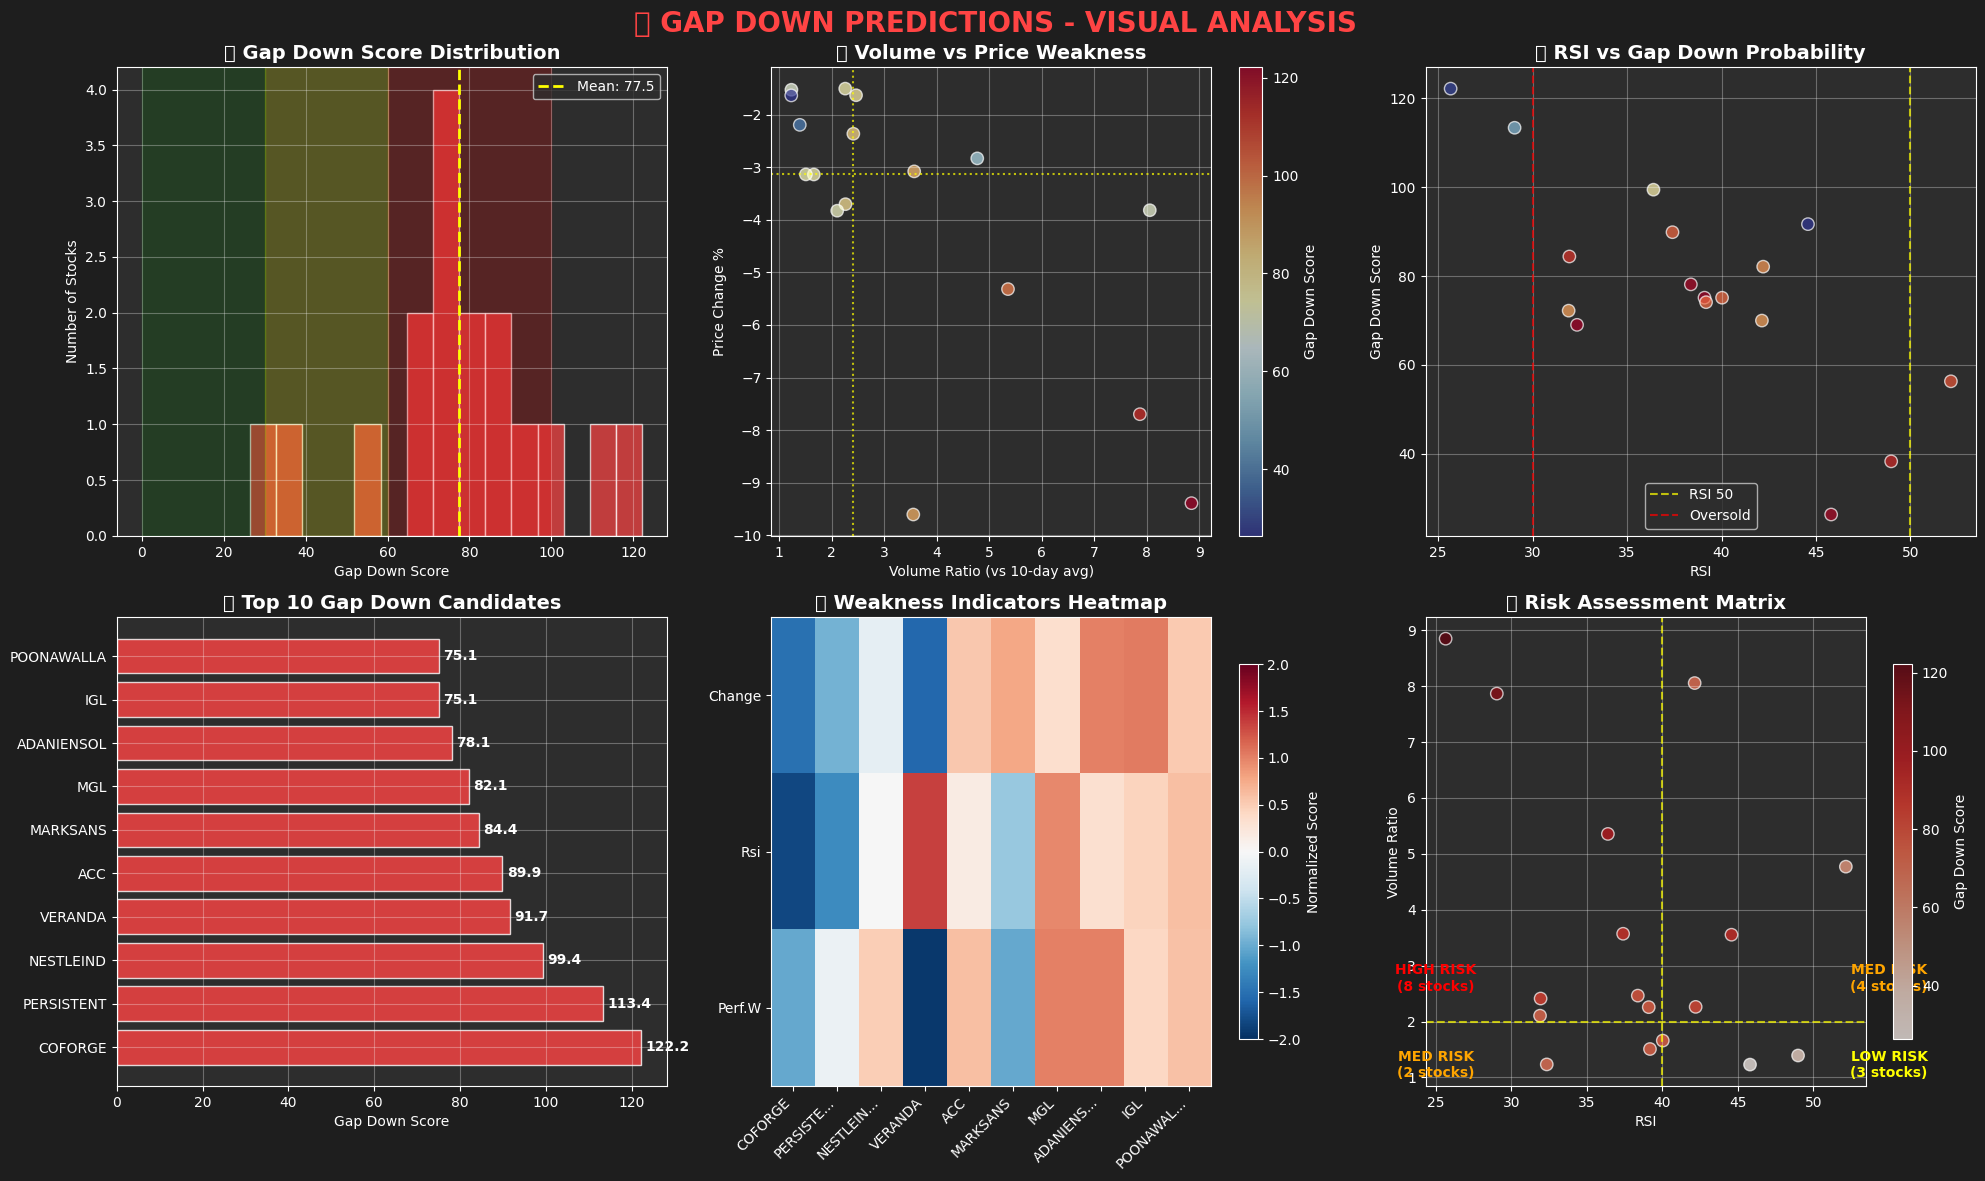


📊 GAP DOWN PROBABILITY BREAKDOWN:
🔴 High Probability (>60): 14 stocks
🟡 Medium Probability (30-60): 2 stocks
🟠 Low Probability (<30): 1 stocks


In [6]:
# Visual Analysis of Gap Down Candidates
if gap_down_df is not None and len(gap_down_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('📉 GAP DOWN PREDICTIONS - VISUAL ANALYSIS', fontsize=20, fontweight='bold', color='#ff4444')
    
    # 1. Gap Down Score Distribution (Top Left)
    ax1 = axes[0, 0]
    ax1.hist(gap_down_df['gap_down_score'], bins=15, color='#ff4444', alpha=0.7, edgecolor='white')
    ax1.axvline(gap_down_df['gap_down_score'].mean(), color='#ffff00', linestyle='--', linewidth=2, 
               label=f'Mean: {gap_down_df["gap_down_score"].mean():.1f}')
    ax1.set_title('🎯 Gap Down Score Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Gap Down Score')
    ax1.set_ylabel('Number of Stocks')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add score interpretation
    ax1.axvspan(0, 30, alpha=0.2, color='green', label='Low Probability')
    ax1.axvspan(30, 60, alpha=0.2, color='yellow', label='Medium Probability')
    ax1.axvspan(60, 100, alpha=0.2, color='red', label='High Probability')
    
    # 2. Volume vs Price Change Scatter (Top Middle)
    ax2 = axes[0, 1]
    scatter = ax2.scatter(gap_down_df['relative_volume_10d_calc'], gap_down_df['change'], 
                         c=gap_down_df['gap_down_score'], cmap='RdYlBu_r', s=80, alpha=0.7, edgecolor='white')
    ax2.set_title('📊 Volume vs Price Weakness', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Volume Ratio (vs 10-day avg)')
    ax2.set_ylabel('Price Change %')
    plt.colorbar(scatter, ax=ax2, label='Gap Down Score')
    ax2.grid(True, alpha=0.3)
    
    # Add quadrant lines
    ax2.axhline(y=gap_down_df['change'].median(), color='yellow', linestyle=':', alpha=0.7)
    ax2.axvline(x=gap_down_df['relative_volume_10d_calc'].median(), color='yellow', linestyle=':', alpha=0.7)
    
    # 3. RSI vs Gap Score (Top Right)
    ax3 = axes[0, 2]
    ax3.scatter(gap_down_df['RSI'], gap_down_df['gap_down_score'], 
               c=gap_down_df['change'], cmap='RdYlBu_r', s=80, alpha=0.7, edgecolor='white')
    ax3.set_title('📈 RSI vs Gap Down Probability', fontsize=14, fontweight='bold')
    ax3.set_xlabel('RSI')
    ax3.set_ylabel('Gap Down Score')
    ax3.axvline(x=50, color='yellow', linestyle='--', alpha=0.7, label='RSI 50')
    ax3.axvline(x=30, color='red', linestyle='--', alpha=0.7, label='Oversold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Top 10 Candidates Bar Chart (Bottom Left)
    ax4 = axes[1, 0]
    top_10 = gap_down_df.head(10)
    colors = ['#ff4444' if score > 60 else '#ffaa44' if score > 30 else '#ffff44' 
              for score in top_10['gap_down_score']]
    
    bars = ax4.barh(range(len(top_10)), top_10['gap_down_score'], color=colors, alpha=0.8, edgecolor='white')
    ax4.set_yticks(range(len(top_10)))
    ax4.set_yticklabels([name[:10] + '...' if len(name) > 10 else name for name in top_10['name']])
    ax4.set_title('📉 Top 10 Gap Down Candidates', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Gap Down Score')
    
    # Add score labels
    for i, (bar, score) in enumerate(zip(bars, top_10['gap_down_score'])):
        ax4.text(score + 1, i, f'{score:.1f}', ha='left', va='center', fontweight='bold')
    ax4.grid(True, alpha=0.3)
    
    # 5. Weakness Indicators Heatmap (Bottom Middle)
    ax5 = axes[1, 1]
    weakness_cols = ['change', 'RSI', 'Perf.W']
    available_weakness = [col for col in weakness_cols if col in gap_down_df.columns]
    
    if available_weakness:
        weakness_data = top_10[available_weakness].fillna(0)
        # Normalize for better visualization
        weakness_normalized = (weakness_data - weakness_data.mean()) / weakness_data.std()
        
        im = ax5.imshow(weakness_normalized.T, cmap='RdBu_r', aspect='auto', 
                       vmin=-2, vmax=2)
        
        ax5.set_xticks(range(len(top_10)))
        ax5.set_xticklabels([name[:8] + '...' if len(name) > 8 else name for name in top_10['name']], 
                           rotation=45, ha='right')
        ax5.set_yticks(range(len(available_weakness)))
        ax5.set_yticklabels([col.replace('_', ' ').title() for col in available_weakness])
        ax5.set_title('🌡️ Weakness Indicators Heatmap', fontsize=14, fontweight='bold')
        
        plt.colorbar(im, ax=ax5, shrink=0.8, label='Normalized Score')
    else:
        ax5.text(0.5, 0.5, 'Weakness data\nnot available', ha='center', va='center', 
                transform=ax5.transAxes, fontsize=12, color='yellow')
    
    # 6. Risk Assessment Matrix (Bottom Right)
    ax6 = axes[1, 2]
    if all(col in gap_down_df.columns for col in ['RSI', 'relative_volume_10d_calc']):
        # Create risk quadrants
        rsi_threshold = 40
        vol_threshold = 2.0
        
        # Quadrant 1: Low RSI + High Volume = High Risk
        q1 = gap_down_df[(gap_down_df['RSI'] < rsi_threshold) & 
                        (gap_down_df['relative_volume_10d_calc'] > vol_threshold)]
        
        # Quadrant 2: Low RSI + Low Volume = Medium Risk
        q2 = gap_down_df[(gap_down_df['RSI'] < rsi_threshold) & 
                        (gap_down_df['relative_volume_10d_calc'] <= vol_threshold)]
        
        # Quadrant 3: High RSI + High Volume = Medium Risk
        q3 = gap_down_df[(gap_down_df['RSI'] >= rsi_threshold) & 
                        (gap_down_df['relative_volume_10d_calc'] > vol_threshold)]
        
        # Quadrant 4: High RSI + Low Volume = Low Risk
        q4 = gap_down_df[(gap_down_df['RSI'] >= rsi_threshold) & 
                        (gap_down_df['relative_volume_10d_calc'] <= vol_threshold)]
        
        scatter = ax6.scatter(gap_down_df['RSI'], gap_down_df['relative_volume_10d_calc'], 
                             c=gap_down_df['gap_down_score'], cmap='Reds', s=80, alpha=0.7, edgecolor='white')
        
        ax6.axvline(x=rsi_threshold, color='yellow', linestyle='--', alpha=0.7)
        ax6.axhline(y=vol_threshold, color='yellow', linestyle='--', alpha=0.7)
        
        # Add quadrant labels
        ax6.text(25, vol_threshold + 0.5, f'HIGH RISK\n({len(q1)} stocks)', 
                ha='center', va='bottom', fontweight='bold', color='red')
        ax6.text(25, vol_threshold - 0.5, f'MED RISK\n({len(q2)} stocks)', 
                ha='center', va='top', fontweight='bold', color='orange')
        ax6.text(55, vol_threshold + 0.5, f'MED RISK\n({len(q3)} stocks)', 
                ha='center', va='bottom', fontweight='bold', color='orange')
        ax6.text(55, vol_threshold - 0.5, f'LOW RISK\n({len(q4)} stocks)', 
                ha='center', va='top', fontweight='bold', color='yellow')
        
        ax6.set_title('🎯 Risk Assessment Matrix', fontsize=14, fontweight='bold')
        ax6.set_xlabel('RSI')
        ax6.set_ylabel('Volume Ratio')
        plt.colorbar(scatter, ax=ax6, shrink=0.8, label='Gap Down Score')
        ax6.grid(True, alpha=0.3)
    else:
        ax6.text(0.5, 0.5, 'Risk assessment\ndata not available', ha='center', va='center', 
                transform=ax6.transAxes, fontsize=12, color='yellow')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    high_prob = len(gap_down_df[gap_down_df['gap_down_score'] > 60])
    med_prob = len(gap_down_df[(gap_down_df['gap_down_score'] > 30) & (gap_down_df['gap_down_score'] <= 60)])
    low_prob = len(gap_down_df[gap_down_df['gap_down_score'] <= 30])
    
    print(f"\n📊 GAP DOWN PROBABILITY BREAKDOWN:")
    print(f"🔴 High Probability (>60): {high_prob} stocks")
    print(f"🟡 Medium Probability (30-60): {med_prob} stocks")
    print(f"🟠 Low Probability (<30): {low_prob} stocks")
    
else:
    print("No gap down data available for visualization")

## 🩳 Short Opportunity Analysis

Identifying high-probability short opportunities based on:
- Technical breakdown patterns
- Overbought conditions with weakness
- Volume confirmation
- Risk-reward ratios

In [7]:
def get_short_opportunities():
    """Screen for high-probability SHORT opportunities in QUALITY stocks"""
    col = Column
    
    short_query = (Query()
        .select('name', 'close', 'change', 'volume', 'high', 'low',
                'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                'EMA20', 'EMA50', 'EMA200', 'BB.upper', 'BB.lower', 'ATR',
                'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                'market_cap_basic', 'Stoch.RSI.K', 'ADX', 'price_earnings_ttm',
                'sector', 'beta_1_year')
        .set_markets('india')
        .where(
            col('market_cap_basic') > 25_000_000_000,  # 25B+ market cap (LARGE CAP for easy shorting)
            col('close') > 500,  # Minimum ₹500 price (HIGH QUALITY STOCKS ONLY)
            col('RSI') > 65,  # Overbought condition
            col('change') < -0.5,  # Showing weakness despite being overbought
            col('relative_volume_10d_calc') > 1.3,  # Above average volume
            col('close') < col('high'),  # Not at session high
            col('volume') > 2_000_000,  # VERY HIGH liquidity for shorting
            col('beta_1_year') > 0.8  # Not too defensive
        )
        .order_by('RSI', ascending=False)  # Most overbought first
        .limit(20))
    
    try:
        data = short_query.get_scanner_data(cookies=tv_cookies)
        if data and len(data) >= 2 and len(data[1]) > 0:
            df = data[1]
            
            # Convert numeric columns
            numeric_cols = ['close', 'change', 'volume', 'high', 'low',
                          'relative_volume_10d_calc', 'RSI', 'MACD.macd', 'MACD.signal',
                          'EMA20', 'EMA50', 'EMA200', 'BB.upper', 'BB.lower', 'ATR',
                          'Perf.W', 'Perf.3M', 'price_52_week_high', 'price_52_week_low',
                          'market_cap_basic', 'Stoch.RSI.K', 'ADX', 'price_earnings_ttm',
                          'beta_1_year']
            
            for col_name in numeric_cols:
                if col_name in df.columns:
                    df[col_name] = pd.to_numeric(df[col_name], errors='coerce')
            
            # Calculate short opportunity scores
            df['short_score'] = 0
            
            # Overbought condition (30% weight)
            if 'RSI' in df.columns:
                df['short_score'] += np.clip((df['RSI'] - 50) * 0.6, 0, 30)
            
            # Price weakness despite overbought (25% weight)
            if 'change' in df.columns:
                df['short_score'] += np.clip(abs(df['change']) * 5, 0, 25)
            
            # Volume confirmation (25% weight)
            if 'relative_volume_10d_calc' in df.columns:
                df['short_score'] += np.clip(df['relative_volume_10d_calc'] * 8, 0, 25)
            
            # Technical breakdown (20% weight)
            breakdown_score = 0
            
            # Below key EMAs
            if all(col in df.columns for col in ['close', 'EMA20']):
                breakdown_score += np.where(df['close'] < df['EMA20'], 5, 0)
            if all(col in df.columns for col in ['close', 'EMA50']):
                breakdown_score += np.where(df['close'] < df['EMA50'], 5, 0)
            
            # MACD bearish
            if all(col in df.columns for col in ['MACD.macd', 'MACD.signal']):
                breakdown_score += np.where(df['MACD.macd'] < df['MACD.signal'], 5, 0)
            
            # Stochastic RSI overbought
            if 'Stoch.RSI.K' in df.columns:
                breakdown_score += np.where(df['Stoch.RSI.K'] > 80, 5, 0)
            
            df['short_score'] += breakdown_score
            
            # Risk-reward calculation
            if all(col in df.columns for col in ['close', 'EMA50', 'ATR']):
                # Target: EMA50 or 2*ATR below current price
                df['target_price'] = np.minimum(df['EMA50'], df['close'] - (2 * df['ATR']))
                # Stop loss: 1.5*ATR above current price
                df['stop_loss'] = df['close'] + (1.5 * df['ATR'])
                # Risk-reward ratio
                df['risk_reward'] = (df['close'] - df['target_price']) / (df['stop_loss'] - df['close'])
                
                # Bonus for good risk-reward
                df['short_score'] += np.where(df['risk_reward'] > 2, 10, 0)
            
            # Distance from 52-week high bonus
            if all(col in df.columns for col in ['close', 'price_52_week_high']):
                df['distance_from_52w_high'] = ((df['close'] / df['price_52_week_high']) - 1) * 100
                df['short_score'] += np.where(df['distance_from_52w_high'] > -5, 10, 0)  # Near highs
            
            # Quality stock bonus (easier to short large caps)
            if 'market_cap_basic' in df.columns:
                df['short_score'] += np.where(df['market_cap_basic'] > 100_000_000_000, 10, 5)  # 100B+ extra bonus
            
            df = df.sort_values('short_score', ascending=False)
            console.print(f"[green]✅ Found {len(df)} QUALITY short opportunities[/green]")
            return df
        return None
    except Exception as e:
        console.print(f"[red]❌ Short opportunity screening failed: {e}[/red]")
        return None

# Get short opportunities
with console.status("[bold yellow]Scanning for QUALITY short opportunities..."):
    short_df = get_short_opportunities()

if short_df is not None:
    print(f"🩳 Found {len(short_df)} QUALITY Short Opportunities")
    print(f"💎 All stocks have >₹500 price and >₹25,000 Cr market cap")
    print(f"📊 High liquidity (>20L volume) for easy shorting")
    
    # Display top opportunities
    display_cols = ['name', 'close', 'change', 'RSI', 'short_score']
    if 'risk_reward' in short_df.columns:
        display_cols.append('risk_reward')
    
    top_shorts = short_df.head(10)[display_cols]
    col_names = ['Stock', 'Price', 'Change %', 'RSI', 'Short Score']
    if 'risk_reward' in display_cols:
        col_names.append('R:R Ratio')
    
    top_shorts.columns = col_names
    print("\n🩳 TOP QUALITY SHORT OPPORTUNITIES:")
    print(top_shorts.to_string(index=False, float_format='%.2f'))
else:
    print("❌ No quality short opportunities found")

Output()

❌ No quality short opportunities found


In [8]:
# Visual Analysis of Short Opportunities
if short_df is not None and len(short_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('🩳 SHORT OPPORTUNITIES - VISUAL ANALYSIS', fontsize=20, fontweight='bold', color='#ff6600')
    
    # 1. Short Score Distribution (Top Left)
    ax1 = axes[0, 0]
    ax1.hist(short_df['short_score'], bins=12, color='#ff6600', alpha=0.7, edgecolor='white')
    ax1.axvline(short_df['short_score'].mean(), color='#ffff00', linestyle='--', linewidth=2, 
               label=f'Mean: {short_df["short_score"].mean():.1f}')
    ax1.set_title('🎯 Short Score Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Short Score')
    ax1.set_ylabel('Number of Stocks')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add score interpretation zones
    ax1.axvspan(0, 40, alpha=0.2, color='green', label='Low Confidence')
    ax1.axvspan(40, 70, alpha=0.2, color='yellow', label='Medium Confidence')
    ax1.axvspan(70, 100, alpha=0.2, color='red', label='High Confidence')
    
    # 2. RSI vs Price Change (Top Middle)
    ax2 = axes[0, 1]
    scatter = ax2.scatter(short_df['RSI'], short_df['change'], 
                         c=short_df['short_score'], cmap='YlOrRd', s=80, alpha=0.7, edgecolor='white')
    ax2.set_title('📊 Overbought vs Weakness', fontsize=14, fontweight='bold')
    ax2.set_xlabel('RSI (Overbought Level)')
    ax2.set_ylabel('Price Change % (Weakness)')
    ax2.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
    ax2.axhline(y=0, color='yellow', linestyle='-', alpha=0.7, label='Neutral')
    plt.colorbar(scatter, ax=ax2, label='Short Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Risk-Reward Analysis (Top Right)
    ax3 = axes[0, 2]
    if 'risk_reward' in short_df.columns:
        # Filter out extreme values for better visualization
        rr_filtered = short_df[short_df['risk_reward'].between(0, 10)]
        if len(rr_filtered) > 0:
            scatter = ax3.scatter(rr_filtered['risk_reward'], rr_filtered['short_score'], 
                                 c=rr_filtered['RSI'], cmap='Reds', s=80, alpha=0.7, edgecolor='white')
            ax3.axvline(x=2, color='green', linestyle='--', alpha=0.7, label='Good R:R (2:1)')
            ax3.axvline(x=3, color='yellow', linestyle='--', alpha=0.7, label='Great R:R (3:1)')
            ax3.set_title('💰 Risk-Reward Analysis', fontsize=14, fontweight='bold')
            ax3.set_xlabel('Risk:Reward Ratio')
            ax3.set_ylabel('Short Score')
            plt.colorbar(scatter, ax=ax3, label='RSI Level')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
        else:
            ax3.text(0.5, 0.5, 'Risk-Reward\ndata not available', ha='center', va='center', 
                    transform=ax3.transAxes, fontsize=12, color='yellow')
    else:
        # Alternative: Volume vs Score
        ax3.scatter(short_df['relative_volume_10d_calc'], short_df['short_score'], 
                   c=short_df['RSI'], cmap='Reds', s=80, alpha=0.7, edgecolor='white')
        ax3.set_title('📊 Volume vs Short Score', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Volume Ratio')
        ax3.set_ylabel('Short Score')
        ax3.grid(True, alpha=0.3)
    
    # 4. Top Short Candidates (Bottom Left)
    ax4 = axes[1, 0]
    top_10 = short_df.head(10)
    colors = ['#ff3333' if score > 70 else '#ff6600' if score > 40 else '#ffaa00' 
              for score in top_10['short_score']]
    
    bars = ax4.barh(range(len(top_10)), top_10['short_score'], color=colors, alpha=0.8, edgecolor='white')
    ax4.set_yticks(range(len(top_10)))
    ax4.set_yticklabels([name[:10] + '...' if len(name) > 10 else name for name in top_10['name']])
    ax4.set_title('🏆 Top 10 Short Candidates', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Short Score')
    
    # Add score labels and RSI values
    for i, (bar, score, rsi) in enumerate(zip(bars, top_10['short_score'], top_10['RSI'])):
        ax4.text(score + 1, i, f'{score:.1f}\n(RSI:{rsi:.0f})', ha='left', va='center', 
                fontweight='bold', fontsize=8)
    ax4.grid(True, alpha=0.3)
    
    # 5. Entry vs Target Analysis (Bottom Middle)
    ax5 = axes[1, 1]
    if all(col in short_df.columns for col in ['close', 'target_price', 'stop_loss']):
        # Create a chart showing entry, target, and stop levels
        top_5 = short_df.head(5)
        x_pos = range(len(top_5))
        
        # Entry price (current)
        ax5.scatter(x_pos, top_5['close'], color='yellow', s=100, label='Entry Price', marker='o')
        # Target price
        ax5.scatter(x_pos, top_5['target_price'], color='green', s=100, label='Target Price', marker='v')
        # Stop loss
        ax5.scatter(x_pos, top_5['stop_loss'], color='red', s=100, label='Stop Loss', marker='^')
        
        # Connect with lines
        for i, (entry, target, stop) in enumerate(zip(top_5['close'], top_5['target_price'], top_5['stop_loss'])):
            ax5.plot([i, i], [target, stop], 'k--', alpha=0.5)
            ax5.plot([i, i], [entry, target], 'g-', alpha=0.7, linewidth=2)  # Profit potential
            ax5.plot([i, i], [entry, stop], 'r-', alpha=0.7, linewidth=2)    # Risk
        
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels([name[:8] + '...' if len(name) > 8 else name for name in top_5['name']], 
                           rotation=45, ha='right')
        ax5.set_title('🎯 Entry vs Target Levels', fontsize=14, fontweight='bold')
        ax5.set_ylabel('Price Level')
        ax5.legend()
        ax5.grid(True, alpha=0.3)
    else:
        # Alternative: Performance heatmap
        perf_cols = ['change', 'Perf.W', 'Perf.3M']
        available_perf = [col for col in perf_cols if col in short_df.columns]
        
        if available_perf:
            perf_data = top_10[available_perf].fillna(0)
            im = ax5.imshow(perf_data.T, cmap='RdBu_r', aspect='auto')
            ax5.set_xticks(range(len(top_10)))
            ax5.set_xticklabels([name[:8] + '...' if len(name) > 8 else name for name in top_10['name']], 
                               rotation=45, ha='right')
            ax5.set_yticks(range(len(available_perf)))
            ax5.set_yticklabels([col.replace('_', ' ').title() for col in available_perf])
            ax5.set_title('📊 Performance Heatmap', fontsize=14, fontweight='bold')
            plt.colorbar(im, ax=ax5, shrink=0.8)
    
    # 6. Sector Risk Distribution (Bottom Right)
    ax6 = axes[1, 2]
    if 'sector' in short_df.columns:
        sector_risk = short_df.groupby('sector').agg({
            'short_score': 'mean',
            'name': 'count'
        }).round(2)
        sector_risk.columns = ['Avg_Score', 'Count']
        sector_risk = sector_risk.sort_values('Avg_Score', ascending=False).head(8)
        
        if len(sector_risk) > 0:
            bars = ax6.bar(range(len(sector_risk)), sector_risk['Avg_Score'], 
                          color='#ff6600', alpha=0.8, edgecolor='white')
            ax6.set_xticks(range(len(sector_risk)))
            ax6.set_xticklabels([sector[:12] + '...' if len(sector) > 12 else sector 
                                for sector in sector_risk.index], rotation=45, ha='right')
            ax6.set_title('🏢 Sector Risk Distribution', fontsize=14, fontweight='bold')
            ax6.set_ylabel('Average Short Score')
            
            # Add count labels
            for i, (bar, count) in enumerate(zip(bars, sector_risk['Count'])):
                ax6.text(i, bar.get_height() + 1, f'{count} stocks', 
                        ha='center', va='bottom', fontweight='bold', fontsize=8)
            ax6.grid(True, alpha=0.3)
        else:
            ax6.text(0.5, 0.5, 'Sector data\nnot available', ha='center', va='center', 
                    transform=ax6.transAxes, fontsize=12, color='yellow')
    else:
        ax6.text(0.5, 0.5, 'Sector data\nnot available', ha='center', va='center', 
                transform=ax6.transAxes, fontsize=12, color='yellow')
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    high_conf = len(short_df[short_df['short_score'] > 70])
    med_conf = len(short_df[(short_df['short_score'] > 40) & (short_df['short_score'] <= 70)])
    low_conf = len(short_df[short_df['short_score'] <= 40])
    
    print(f"\n📊 SHORT OPPORTUNITY CONFIDENCE BREAKDOWN:")
    print(f"🔴 High Confidence (>70): {high_conf} stocks")
    print(f"🟡 Medium Confidence (40-70): {med_conf} stocks")
    print(f"🟠 Low Confidence (<40): {low_conf} stocks")
    
    if 'risk_reward' in short_df.columns:
        good_rr = len(short_df[short_df['risk_reward'] > 2])
        print(f"💰 Good Risk:Reward (>2:1): {good_rr} opportunities")
    
else:
    print("No short opportunity data available for visualization")

No short opportunity data available for visualization


## 🎯 Tomorrow's Action Plan

Consolidated action plan based on gap and short predictions

In [9]:
# Generate Tomorrow's Action Plan
print("\n" + "=" * 100)
print(f"🎯 TOMORROW'S TRADING ACTION PLAN - {(datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')}")
print("=" * 100)

# Gap Up Opportunities
if gap_up_df is not None and len(gap_up_df) > 0:
    high_prob_gap_up = gap_up_df[gap_up_df['gap_up_score'] > 60]
    print(f"\n📈 GAP UP WATCHLIST ({len(high_prob_gap_up)} HIGH PROBABILITY):")
    if len(high_prob_gap_up) > 0:
        for _, stock in high_prob_gap_up.head(5).iterrows():
            print(f"  🟢 {stock['name']}: Score {stock['gap_up_score']:.1f} | Price ₹{stock['close']:.1f} | Change {stock['change']:.1f}%")
    
    print(f"\n📋 GAP UP STRATEGY:")
    print(f"  • Pre-market: Monitor for 2-5% gap up confirmation")
    print(f"  • Entry: On first pullback after gap up (support test)")
    print(f"  • Stop Loss: Below gap fill level (usually -2% from entry)")
    print(f"  • Target: 5-8% above entry or key resistance levels")

# Gap Down Opportunities  
if gap_down_df is not None and len(gap_down_df) > 0:
    high_prob_gap_down = gap_down_df[gap_down_df['gap_down_score'] > 60]
    print(f"\n📉 GAP DOWN WATCHLIST ({len(high_prob_gap_down)} HIGH PROBABILITY):")
    if len(high_prob_gap_down) > 0:
        for _, stock in high_prob_gap_down.head(5).iterrows():
            print(f"  🔴 {stock['name']}: Score {stock['gap_down_score']:.1f} | Price ₹{stock['close']:.1f} | Change {stock['change']:.1f}%")
    
    print(f"\n📋 GAP DOWN STRATEGY:")
    print(f"  • Pre-market: Monitor for 2-5% gap down confirmation")
    print(f"  • Entry: On bounce failure at resistance (previous support)")
    print(f"  • Stop Loss: Above gap close level (+2% from entry)")
    print(f"  • Target: Next support level or -5-8% from entry")

# Short Opportunities
if short_df is not None and len(short_df) > 0:
    high_conf_shorts = short_df[short_df['short_score'] > 70]
    print(f"\n🩳 SHORT OPPORTUNITIES ({len(high_conf_shorts)} HIGH CONFIDENCE):")
    if len(high_conf_shorts) > 0:
        for _, stock in high_conf_shorts.head(5).iterrows():
            rr_text = f"| R:R {stock['risk_reward']:.1f}:1" if 'risk_reward' in stock and pd.notna(stock['risk_reward']) else ""
            print(f"  🟠 {stock['name']}: Score {stock['short_score']:.1f} | RSI {stock['RSI']:.0f} {rr_text}")
    
    print(f"\n📋 SHORT STRATEGY:")
    print(f"  • Entry: On break below support with volume confirmation")
    print(f"  • Stop Loss: Above recent swing high (usually +2-3%)")
    print(f"  • Target: Next support level or EMA50")
    print(f"  • Risk Management: Position size 1-2% of portfolio max")

# Market Timing
print(f"\n⏰ MARKET TIMING:")
print(f"  • Pre-market (9:00-9:15): Confirm gap predictions, adjust watchlists")
print(f"  • Opening (9:15-9:30): Watch for gap confirmation and volume")
print(f"  • First Hour (9:15-10:15): Primary entry window for gap plays")
print(f"  • Mid-day (11:00-14:00): Monitor for breakdown/breakout continuations")
print(f"  • Last Hour (14:30-15:30): Intraday exit decisions")

# Risk Management Reminders
print(f"\n⚠️ RISK MANAGEMENT CHECKLIST:")
print(f"  ✅ Maximum 2-3% risk per trade")
print(f"  ✅ No more than 10% portfolio in all positions combined")
print(f"  ✅ Pre-defined stop losses for every entry")
print(f"  ✅ Take partial profits at +5% for swing trades")
print(f"  ✅ Trail stops on profitable positions")
print(f"  ✅ No revenge trading if stopped out")

# Market Conditions to Watch
print(f"\n🌍 EXTERNAL FACTORS TO MONITOR:")
print(f"  • Global markets (US futures, Asian markets)")
print(f"  • Currency movement (INR strength/weakness)")
print(f"  • Sectoral news and events")
print(f"  • FII/DII flow data")
print(f"  • VIX levels and market sentiment")

# Summary Stats
total_opportunities = 0
if gap_up_df is not None:
    total_opportunities += len(gap_up_df[gap_up_df['gap_up_score'] > 50])
if gap_down_df is not None:
    total_opportunities += len(gap_down_df[gap_down_df['gap_down_score'] > 50])
if short_df is not None:
    total_opportunities += len(short_df[short_df['short_score'] > 50])

print(f"\n📊 SUMMARY:")
print(f"  🎯 Total High-Probability Opportunities: {total_opportunities}")
print(f"  📈 Gap Up Candidates: {len(gap_up_df) if gap_up_df is not None else 0}")
print(f"  📉 Gap Down Candidates: {len(gap_down_df) if gap_down_df is not None else 0}")
print(f"  🩳 Short Opportunities: {len(short_df) if short_df is not None else 0}")

print("\n" + "=" * 100)
print(f"📱 Save this plan and review at market open tomorrow!")
print(f"🔄 Update analysis if significant overnight news occurs")
print("=" * 100)


🎯 TOMORROW'S TRADING ACTION PLAN - 2025-07-25

📈 GAP UP WATCHLIST (13 HIGH PROBABILITY):
  🟢 VIJAYA: Score 104.9 | Price ₹1121.2 | Change 10.2%
  🟢 POCL: Score 99.8 | Price ₹1095.3 | Change 15.5%
  🟢 IPCALAB: Score 90.9 | Price ₹1540.8 | Change 5.5%
  🟢 SHYAMMETL: Score 89.1 | Price ₹951.9 | Change 2.8%
  🟢 WABAG: Score 81.9 | Price ₹1640.0 | Change 3.0%

📋 GAP UP STRATEGY:
  • Pre-market: Monitor for 2-5% gap up confirmation
  • Entry: On first pullback after gap up (support test)
  • Stop Loss: Below gap fill level (usually -2% from entry)
  • Target: 5-8% above entry or key resistance levels

📉 GAP DOWN WATCHLIST (14 HIGH PROBABILITY):
  🔴 COFORGE: Score 122.2 | Price ₹1676.0 | Change -9.4%
  🔴 PERSISTENT: Score 113.4 | Price ₹5174.0 | Change -7.7%
  🔴 NESTLEIND: Score 99.4 | Price ₹2322.1 | Change -5.3%
  🔴 VERANDA: Score 91.7 | Price ₹221.6 | Change -9.6%
  🔴 ACC: Score 89.9 | Price ₹1890.0 | Change -3.1%

📋 GAP DOWN STRATEGY:
  • Pre-market: Monitor for 2-5% gap down confirmatio

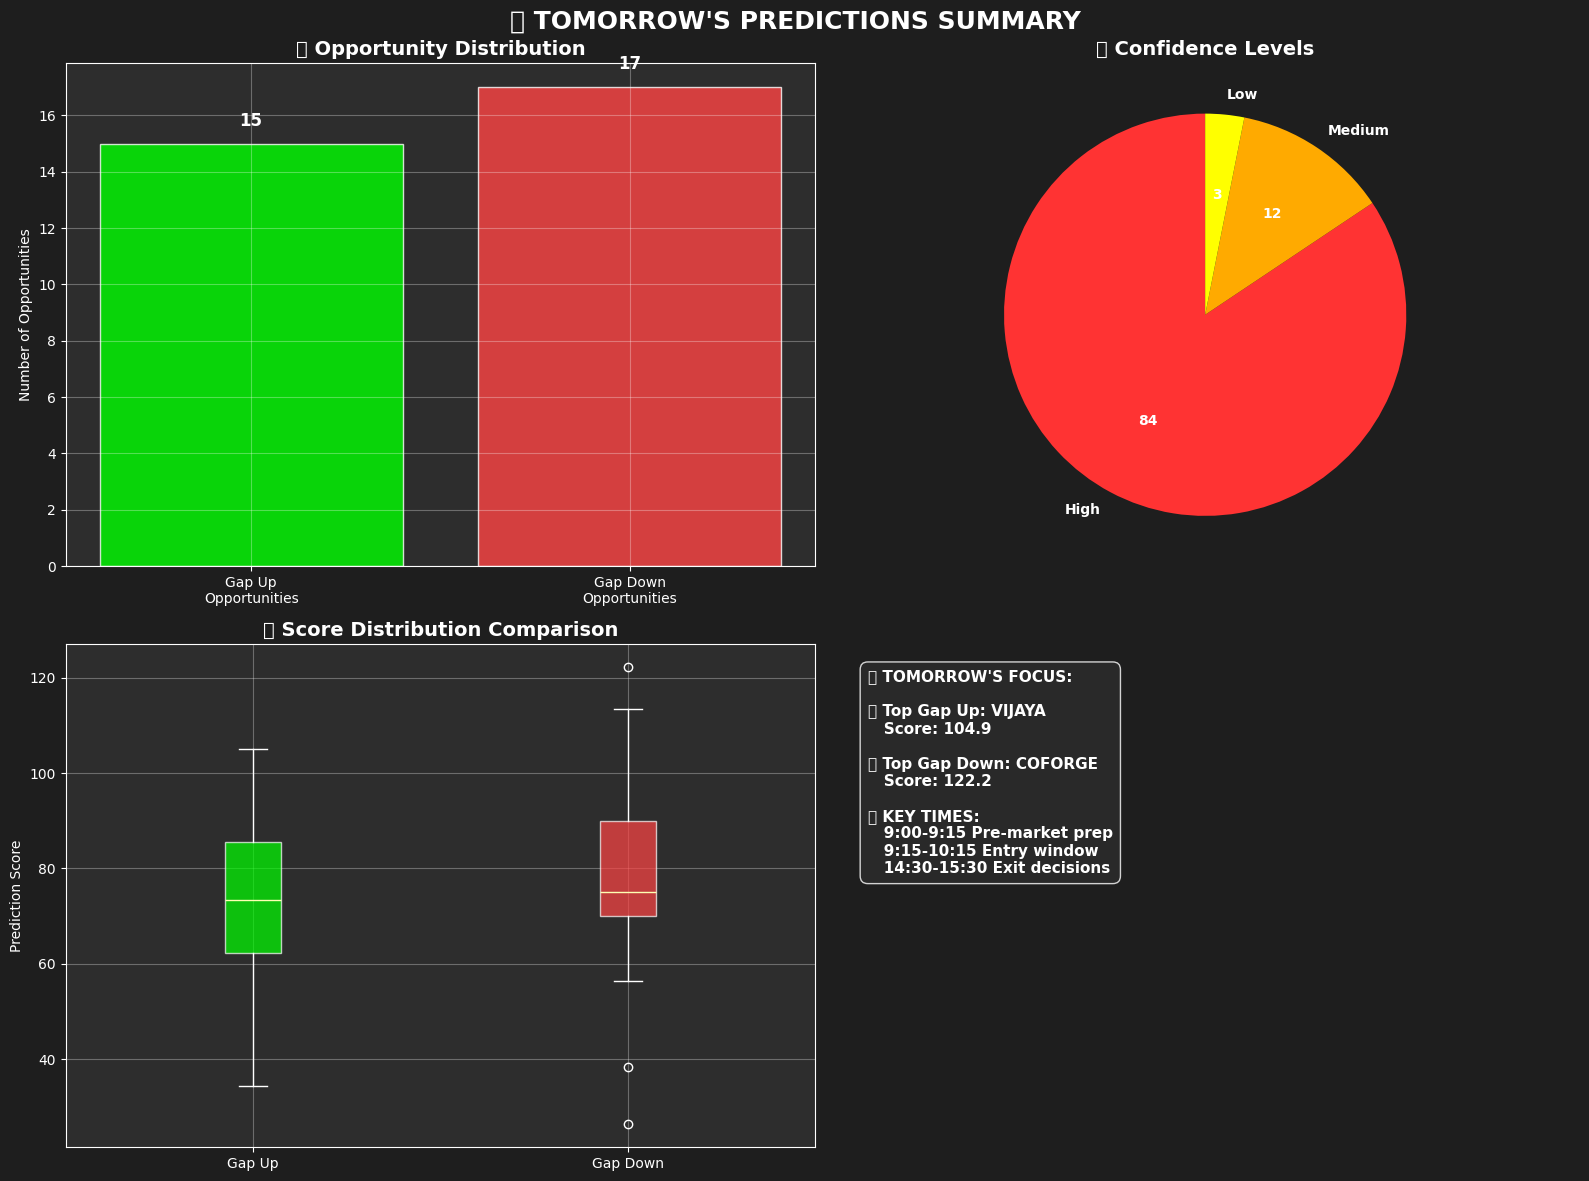


🎉 Tomorrow's Predictions EDA Complete!
📅 Analysis for: 2025-07-25
⏰ Generated at: 2025-07-24 22:52:42


In [10]:
# Create Final Summary Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🔮 TOMORROW\'S PREDICTIONS SUMMARY', fontsize=18, fontweight='bold', color='#ffffff')

# 1. Opportunity Distribution (Top Left)
ax1 = axes[0, 0]
categories = []
values = []
colors = []

if gap_up_df is not None and len(gap_up_df) > 0:
    categories.append('Gap Up\nOpportunities')
    values.append(len(gap_up_df))
    colors.append('#00ff00')

if gap_down_df is not None and len(gap_down_df) > 0:
    categories.append('Gap Down\nOpportunities')
    values.append(len(gap_down_df))
    colors.append('#ff4444')

if short_df is not None and len(short_df) > 0:
    categories.append('Short\nOpportunities')
    values.append(len(short_df))
    colors.append('#ff6600')

if values:
    bars = ax1.bar(categories, values, color=colors, alpha=0.8, edgecolor='white')
    ax1.set_title('📊 Opportunity Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Opportunities')
    
    # Add value labels
    for bar, value in zip(bars, values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(value), ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'No opportunities\nidentified', ha='center', va='center', 
            transform=ax1.transAxes, fontsize=14, color='yellow')

# 2. Confidence Levels (Top Right)
ax2 = axes[0, 1]
confidence_data = {'High': 0, 'Medium': 0, 'Low': 0}

if gap_up_df is not None:
    confidence_data['High'] += len(gap_up_df[gap_up_df['gap_up_score'] > 60])
    confidence_data['Medium'] += len(gap_up_df[(gap_up_df['gap_up_score'] > 30) & (gap_up_df['gap_up_score'] <= 60)])
    confidence_data['Low'] += len(gap_up_df[gap_up_df['gap_up_score'] <= 30])

if gap_down_df is not None:
    confidence_data['High'] += len(gap_down_df[gap_down_df['gap_down_score'] > 60])
    confidence_data['Medium'] += len(gap_down_df[(gap_down_df['gap_down_score'] > 30) & (gap_down_df['gap_down_score'] <= 60)])
    confidence_data['Low'] += len(gap_down_df[gap_down_df['gap_down_score'] <= 30])

if short_df is not None:
    confidence_data['High'] += len(short_df[short_df['short_score'] > 70])
    confidence_data['Medium'] += len(short_df[(short_df['short_score'] > 40) & (short_df['short_score'] <= 70)])
    confidence_data['Low'] += len(short_df[short_df['short_score'] <= 40])

if sum(confidence_data.values()) > 0:
    wedges, texts, autotexts = ax2.pie(confidence_data.values(), 
                                      labels=confidence_data.keys(),
                                      colors=['#ff3333', '#ffaa00', '#ffff00'],
                                      autopct='%1.0f', startangle=90,
                                      textprops={'fontsize': 10, 'fontweight': 'bold'})
    ax2.set_title('🎯 Confidence Levels', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No confidence\ndata available', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=12, color='yellow')

# 3. Score Comparison (Bottom Left)
ax3 = axes[1, 0]
all_scores = []
all_labels = []

if gap_up_df is not None and len(gap_up_df) > 0:
    all_scores.extend(gap_up_df['gap_up_score'].tolist())
    all_labels.extend(['Gap Up'] * len(gap_up_df))

if gap_down_df is not None and len(gap_down_df) > 0:
    all_scores.extend(gap_down_df['gap_down_score'].tolist())
    all_labels.extend(['Gap Down'] * len(gap_down_df))

if short_df is not None and len(short_df) > 0:
    all_scores.extend(short_df['short_score'].tolist())
    all_labels.extend(['Short'] * len(short_df))

if all_scores:
    df_scores = pd.DataFrame({'Score': all_scores, 'Type': all_labels})
    
    # Create violin plot or box plot
    unique_types = df_scores['Type'].unique()
    positions = range(len(unique_types))
    
    box_data = [df_scores[df_scores['Type'] == t]['Score'].values for t in unique_types]
    bp = ax3.boxplot(box_data, positions=positions, patch_artist=True)
    
    # Color the boxes
    box_colors = {'Gap Up': '#00ff00', 'Gap Down': '#ff4444', 'Short': '#ff6600'}
    for patch, box_type in zip(bp['boxes'], unique_types):
        patch.set_facecolor(box_colors.get(box_type, '#ffffff'))
        patch.set_alpha(0.7)
    
    ax3.set_xticks(positions)
    ax3.set_xticklabels(unique_types)
    ax3.set_title('📊 Score Distribution Comparison', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Prediction Score')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No score data\navailable', ha='center', va='center', 
            transform=ax3.transAxes, fontsize=12, color='yellow')

# 4. Tomorrow's Focus Areas (Bottom Right)
ax4 = axes[1, 1]
ax4.axis('off')

focus_text = "🎯 TOMORROW'S FOCUS:\n\n"

if gap_up_df is not None and len(gap_up_df) > 0:
    top_gap_up = gap_up_df.iloc[0]
    focus_text += f"📈 Top Gap Up: {top_gap_up['name']}\n"
    focus_text += f"   Score: {top_gap_up['gap_up_score']:.1f}\n\n"

if gap_down_df is not None and len(gap_down_df) > 0:
    top_gap_down = gap_down_df.iloc[0]
    focus_text += f"📉 Top Gap Down: {top_gap_down['name']}\n"
    focus_text += f"   Score: {top_gap_down['gap_down_score']:.1f}\n\n"

if short_df is not None and len(short_df) > 0:
    top_short = short_df.iloc[0]
    focus_text += f"🩳 Top Short: {top_short['name']}\n"
    focus_text += f"   Score: {top_short['short_score']:.1f}\n\n"

focus_text += "⏰ KEY TIMES:\n"
focus_text += "   9:00-9:15 Pre-market prep\n"
focus_text += "   9:15-10:15 Entry window\n"
focus_text += "   14:30-15:30 Exit decisions"

ax4.text(0.05, 0.95, focus_text, transform=ax4.transAxes, fontsize=11, 
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#2d2d2d', alpha=0.8, edgecolor='white'))

plt.tight_layout()
plt.show()

print(f"\n🎉 Tomorrow's Predictions EDA Complete!")
print(f"📅 Analysis for: {(datetime.now() + timedelta(days=1)).strftime('%Y-%m-%d')}")
print(f"⏰ Generated at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

---
## 📝 Notes

**Disclaimer:** This analysis is for educational purposes only. Past performance does not guarantee future results. Always do your own research and risk management.

**Next Steps:**
1. Save this notebook output
2. Set up alerts for top candidates
3. Review pre-market activity tomorrow
4. Execute trades with proper risk management

**Recommended Review Time:** 30 minutes before market open